# COMP8430 Phase 3 — Training & Evaluation Notebook
# Robot-Based Fine-Tuning, Evaluation and Deployment

**Group:** 14

**Group Members:**
- Sudipta Nath (48548219)
- Sabiha Samad (48300047)
- Md Ifthekher Uddin (48546356)
- Nafisa Nawer (48642517)
- Joya Akter (48571555)
- Imran Hossain Imon (48445797)

**Three deployment classes:** Cocacola_classic · Sprite · Redbull_Classic

**Pipeline:**
1. Train on all 20 classes (Phase 2 clean dataset)
2. Evaluate Phase 2 model on robot-captured images — BEFORE fine-tuning
3. Fine-tune on 3-class robot data
4. Evaluate again — AFTER fine-tuning
5. Before vs After comparison

In [39]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Fixed 3 deployment classes
THREE_CLASSES = ['Cocacola_classic', 'Sprite', 'Redbull_Classic']

print('Project root:', PROJECT_ROOT)
print('Deployment classes:', THREE_CLASSES)

Project root: /Users/sudiptanath/Desktop/comp8430-ros-image-capture/phase3_robot_classifier
Deployment classes: ['Cocacola_classic', 'Sprite', 'Redbull_Classic']


## 1. Dataset Overview — Phase 2 Clean Dataset (20 Classes)

Total classes: 20  |  Total images: 5726


,Class,Images
0,Redbull_Classic,750
1,Oxyshred_Passion,650
2,Redbull_zero,550
3,Sprite,310
4,Boss_latte,301
5,H2coco,300
6,Monster,261
7,H2coco_choc,257
8,Cocacola_classic,256
9,Sunkist,212


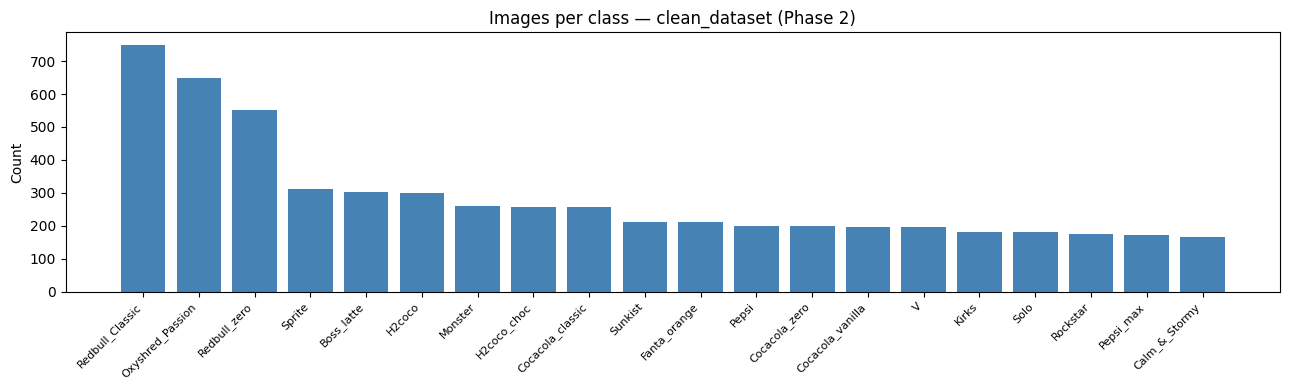

In [40]:
clean_dataset = PROJECT_ROOT / '../dataset/clean_dataset'
class_counts = {}
for cls_dir in sorted(clean_dataset.iterdir()):
    if cls_dir.is_dir():
        n = sum(1 for f in cls_dir.iterdir()
                if f.suffix.lower() in {'.jpg','.jpeg','.png'})
        class_counts[cls_dir.name] = n

df = pd.DataFrame(list(class_counts.items()), columns=['Class','Images'])
df = df.sort_values('Images', ascending=False).reset_index(drop=True)
print(f'Total classes: {len(df)}  |  Total images: {df.Images.sum()}')
display(df)

plt.figure(figsize=(13,4))
plt.bar(df.Class, df.Images, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title('Images per class — clean_dataset (Phase 2)')
plt.ylabel('Count')
plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/dataset_distribution.png', dpi=150)
plt.show()

## 2. Three Selected Deployment Classes

**Selected:** Cocacola_classic, Sprite, Redbull_Classic

**Reason:** These three classes were selected for robot deployment because:
- They are visually distinct from each other (red can, green can, blue/silver can)
- They represent the most common energy/soft drink categories
- Robot-captured images were available for all three classes
- They present a realistic fine-grained classification challenge

In [41]:
ACTIONS = {
    'Cocacola_classic': 'Move forward toward can',
    'Sprite':           'Move forward toward can',
    'Redbull_Classic':  'Move forward toward can',
}

print('Deployment classes and robot actions:')
for cls in THREE_CLASSES:
    cls_path = clean_dataset / cls
    if cls_path.exists():
        n = sum(1 for f in cls_path.iterdir()
                if f.suffix.lower() in {'.jpg','.jpeg','.png'})
        print(f'  {cls}: {n} images in clean_dataset → action: {ACTIONS[cls]}')
    else:
        print(f'  {cls}: not found in clean_dataset')

Deployment classes and robot actions:
  Cocacola_classic: 256 images in clean_dataset → action: Move forward toward can
  Sprite: 310 images in clean_dataset → action: Move forward toward can
  Redbull_Classic: 750 images in clean_dataset → action: Move forward toward can


## 3. Robot-Captured Images Overview

Images captured using the robot embedded camera and selected from the cropped dataset.
These represent real deployment conditions — different lighting, angles, and backgrounds.

Robot classes  : 3
Total images   : 163


,Class,Robot Images
0,Sprite,62
1,Cocacola_classic,51
2,Redbull_Classic,50


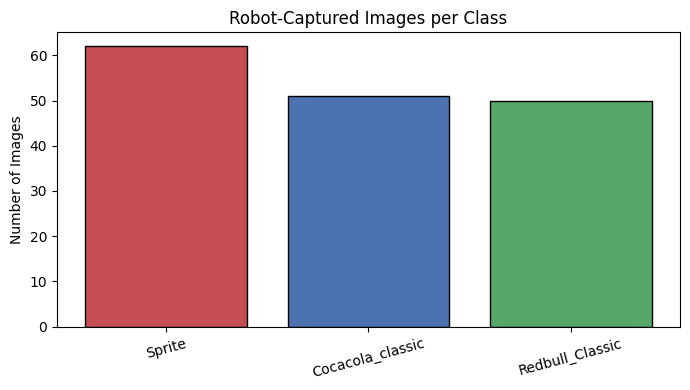

In [42]:
robot_data = PROJECT_ROOT / '../dataset/phase3_robot_data'

if robot_data.exists():
    robot_counts = {}
    for cls_dir in sorted(robot_data.iterdir()):
        if cls_dir.is_dir():
            n = sum(1 for f in cls_dir.iterdir()
                    if f.suffix.lower() in {'.jpg','.jpeg','.png'})
            robot_counts[cls_dir.name] = n

    df_robot = pd.DataFrame(
        list(robot_counts.items()),
        columns=['Class','Robot Images'])
    df_robot = df_robot.sort_values(
        'Robot Images', ascending=False).reset_index(drop=True)

    print(f'Robot classes  : {len(df_robot)}')
    print(f'Total images   : {df_robot["Robot Images"].sum()}')
    display(df_robot)

    # Bar chart
    colors = ['#C44E52', '#4C72B0', '#55A868']
    plt.figure(figsize=(7, 4))
    plt.bar(df_robot.Class, df_robot['Robot Images'],
            color=colors[:len(df_robot)], edgecolor='black')
    plt.title('Robot-Captured Images per Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('../outputs/plots/robot_data_distribution.png', dpi=150)
    plt.show()
else:
    print('Robot data not found at ../dataset/phase3_robot_data/')

## 3b. Sample Robot-Captured Images

Below are sample images from each of the 3 deployment classes captured using the robot camera.

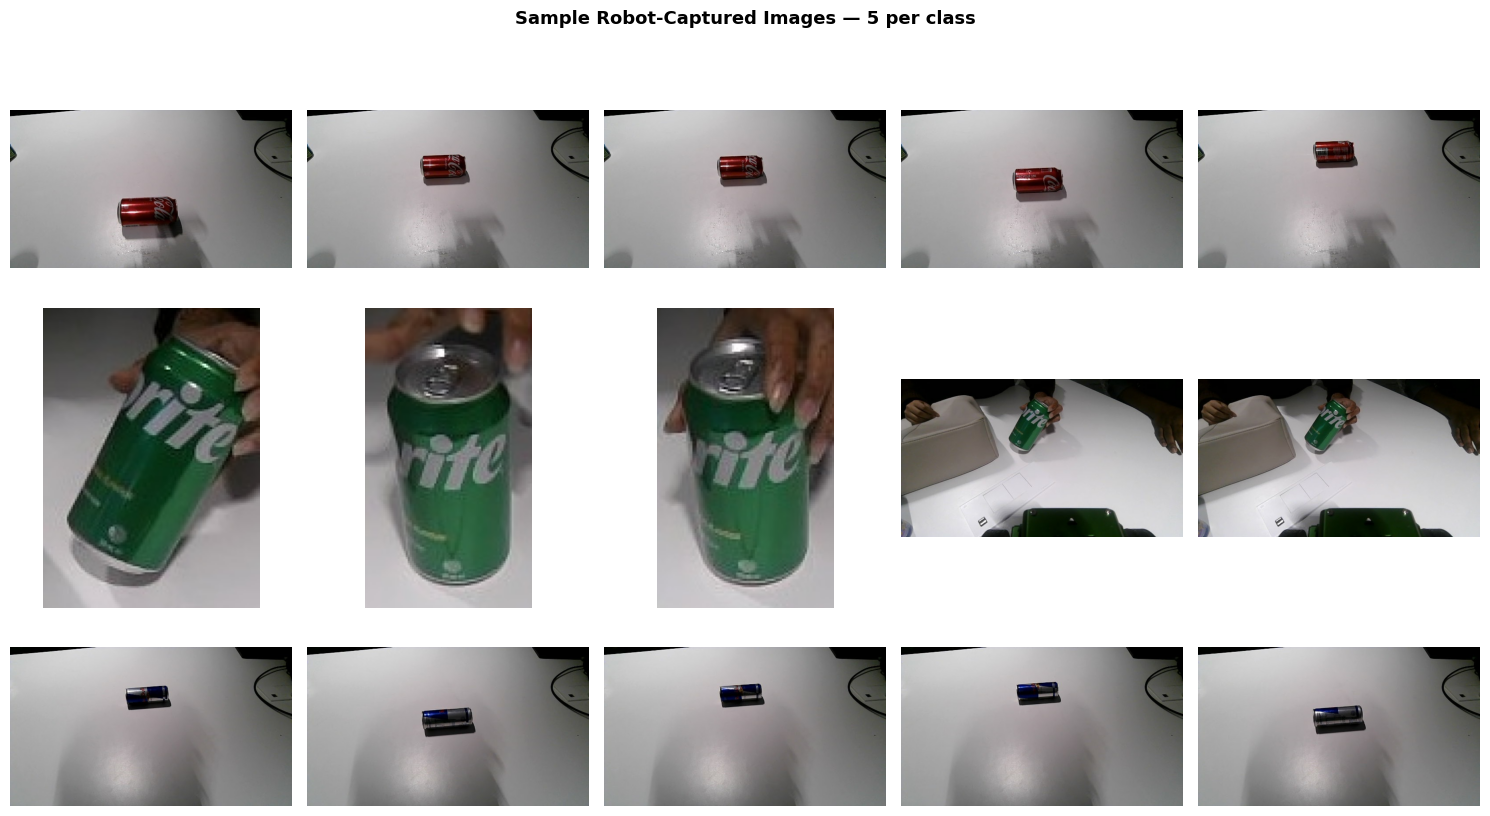

Sample images saved.


In [43]:
import random
from PIL import Image as PILImage

random.seed(42)
robot_data = PROJECT_ROOT / '../dataset/phase3_robot_data'

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for row, cls in enumerate(THREE_CLASSES):
    cls_dir = robot_data / cls
    imgs = [f for f in cls_dir.iterdir()
            if f.suffix.lower() in {'.jpg','.jpeg','.png'}]
    selected = random.sample(imgs, min(5, len(imgs)))
    for col, img_path in enumerate(selected):
        img = PILImage.open(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(
                cls, fontsize=9, fontweight='bold',
                rotation=0, ha='right', va='center')
    for col in range(len(selected), 5):
        axes[row][col].axis('off')

plt.suptitle(
    'Sample Robot-Captured Images — 5 per class',
    fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs/plots', exist_ok=True)
plt.savefig('../outputs/plots/robot_sample_images.png', dpi=150)
plt.show()
print('Sample images saved.')

## 4. Training Curves — All 20 Classes (Phase 2 Clean Dataset)

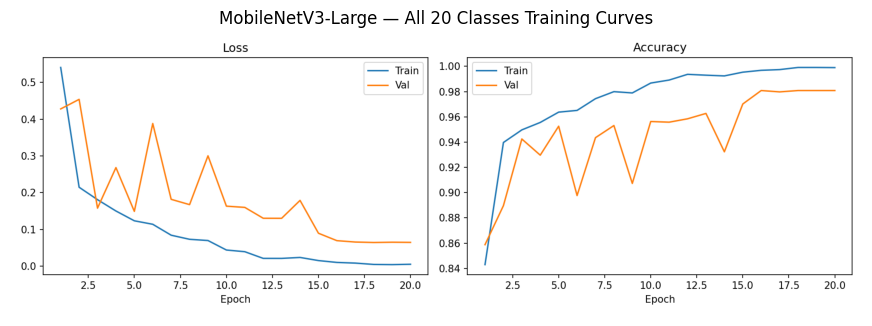

In [44]:
path = '../outputs/plots/all_class_train_curves.png'
if os.path.exists(path):
    plt.figure(figsize=(11,4))
    plt.imshow(mpimg.imread(path))
    plt.axis('off')
    plt.title('MobileNetV3-Large — All 20 Classes Training Curves')
    plt.show()
else:
    print('Training curves not found.')
    print('Run: python train_all_classes.py --data-dir ../dataset/clean_dataset --epochs 20')

## 5. Evaluation BEFORE Robot Fine-Tuning

The Phase 2 model (trained on all 20 classes from clean_dataset) is tested directly
on the robot-captured images without any fine-tuning.
This shows how well the model generalises to robot camera conditions.

In [45]:
path = '../outputs/logs/before_robot_finetune_metrics.json'
if os.path.exists(path):
    m = json.load(open(path))
    print('=== BEFORE Robot Fine-Tuning ===')
    print(f'  Accuracy         : {m["accuracy"]:.4f}')
    print(f'  F1 Macro         : {m["f1_macro"]:.4f}')
    print(f'  F1 Weighted      : {m["f1_weighted"]:.4f}')
    print(f'  Precision Macro  : {m["precision_macro"]:.4f}')
    print(f'  Recall Macro     : {m["recall_macro"]:.4f}')
    print('\n  Per-class accuracy (3 deployment classes):')
    for cls in THREE_CLASSES:
        acc = m['per_class_accuracy'].get(cls, 'N/A')
        print(f'    {cls}: {acc}')
else:
    print('Metrics not found.')
    print('Run: python evaluate.py \\')
    print('  --data-dir   ../dataset/phase3_robot_data \\')
    print('  --model-path outputs/models/all_class_model.pth \\')
    print('  --tag        before_robot_finetune')

=== BEFORE Robot Fine-Tuning ===
  Accuracy         : 1.0000
  F1 Macro         : 1.0000
  F1 Weighted      : 1.0000
  Precision Macro  : 1.0000
  Recall Macro     : 1.0000

  Per-class accuracy (3 deployment classes):
    Cocacola_classic: 1.0
    Sprite: 1.0
    Redbull_Classic: 1.0


## 6. Confusion Matrix — Before Fine-Tuning

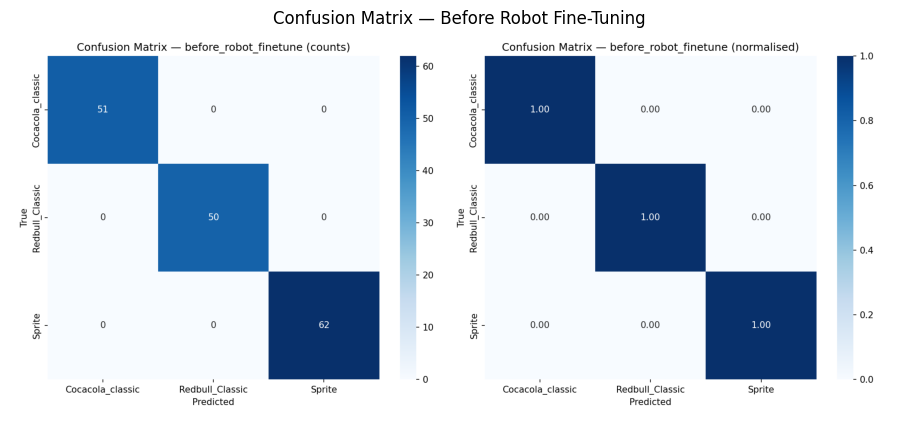

In [46]:
path = '../outputs/plots/before_robot_finetune_confusion_matrix.png'
if os.path.exists(path):
    plt.figure(figsize=(12,5))
    plt.imshow(mpimg.imread(path))
    plt.axis('off')
    plt.title('Confusion Matrix — Before Robot Fine-Tuning')
    plt.show()
else:
    print('Confusion matrix not found. Run evaluate.py first.')

## 7. Fine-Tuning on Robot Data — 3 Classes

The model is fine-tuned specifically on the 3 selected classes using robot-captured images.
This adapts the model to the robot camera characteristics.

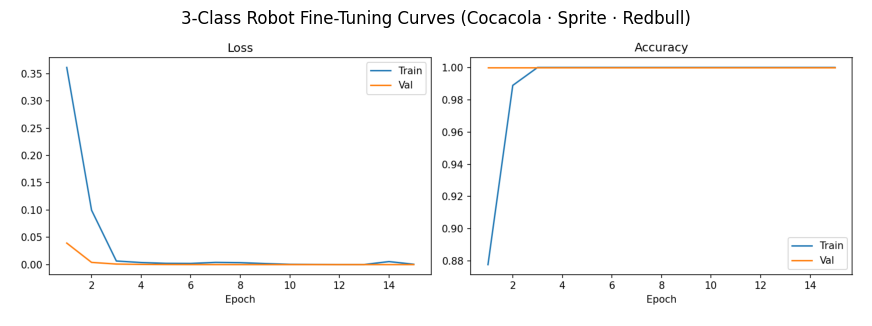

In [47]:
path = '../outputs/plots/three_class_train_curves.png'
if os.path.exists(path):
    plt.figure(figsize=(11,4))
    plt.imshow(mpimg.imread(path))
    plt.axis('off')
    plt.title('3-Class Robot Fine-Tuning Curves (Cocacola · Sprite · Redbull)')
    plt.show()
else:
    print('Training curves not found.')
    print('Run: python train_three_classes.py \\')
    print('  --robot-dir  ../dataset/robot_split \\')
    print('  --output-dir ../dataset/three_class_final \\')
    print('  --base-model outputs/models/all_class_model.pth \\')
    print('  --epochs 15')

## 8. Evaluation AFTER Robot Fine-Tuning

In [48]:
path = '../outputs/logs/after_robot_finetune_metrics.json'
if os.path.exists(path):
    m = json.load(open(path))
    print('=== AFTER Robot Fine-Tuning ===')
    print(f'  Accuracy         : {m["accuracy"]:.4f}')
    print(f'  F1 Macro         : {m["f1_macro"]:.4f}')
    print(f'  F1 Weighted      : {m["f1_weighted"]:.4f}')
    print(f'  Precision Macro  : {m["precision_macro"]:.4f}')
    print(f'  Recall Macro     : {m["recall_macro"]:.4f}')
    print('\n  Per-class accuracy (3 deployment classes):')
    for cls in THREE_CLASSES:
        acc = m['per_class_accuracy'].get(cls, 'N/A')
        print(f'    {cls}: {acc}')
else:
    print('Metrics not found.')
    print('Run: python evaluate.py \\')
    print('  --data-dir   ../dataset/three_class_final/test \\')
    print('  --model-path outputs/models/three_class_robot_model.pth \\')
    print('  --tag        after_robot_finetune')

=== AFTER Robot Fine-Tuning ===
  Accuracy         : 1.0000
  F1 Macro         : 1.0000
  F1 Weighted      : 1.0000
  Precision Macro  : 1.0000
  Recall Macro     : 1.0000

  Per-class accuracy (3 deployment classes):
    Cocacola_classic: 1.0
    Sprite: 1.0
    Redbull_Classic: 1.0


## 9. Confusion Matrix — After Fine-Tuning

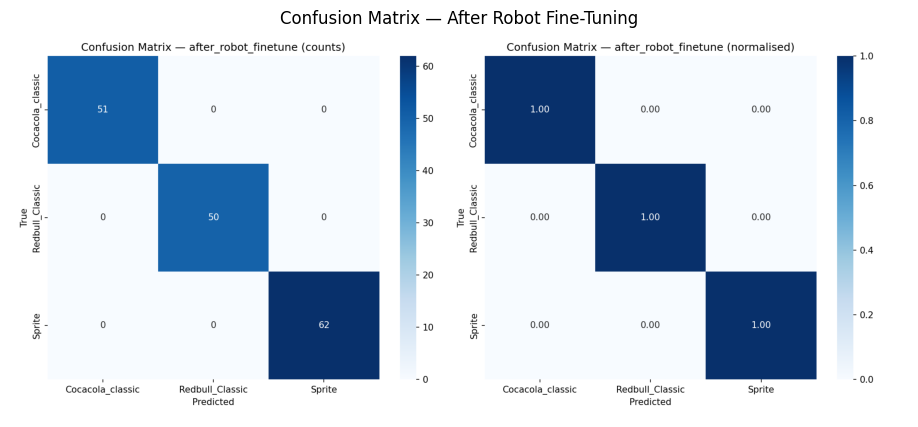

In [49]:
path = '../outputs/plots/after_robot_finetune_confusion_matrix.png'
if os.path.exists(path):
    plt.figure(figsize=(12,5))
    plt.imshow(mpimg.imread(path))
    plt.axis('off')
    plt.title('Confusion Matrix — After Robot Fine-Tuning')
    plt.show()
else:
    print('Confusion matrix not found. Run evaluate.py first.')

## 10. Before vs After Comparison Table

In [50]:
b_path = '../outputs/logs/before_robot_finetune_metrics.json'
a_path = '../outputs/logs/after_robot_finetune_metrics.json'

if os.path.exists(b_path) and os.path.exists(a_path):
    b = json.load(open(b_path))
    a = json.load(open(a_path))

    # Overall metrics comparison
    comp = {
        'Model': ['Before robot fine-tune', 'After robot fine-tune'],
        'Accuracy':    [b['accuracy'],         a['accuracy']],
        'F1 Macro':    [b['f1_macro'],          a['f1_macro']],
        'F1 Weighted': [b['f1_weighted'],       a['f1_weighted']],
        'Precision':   [b['precision_macro'],   a['precision_macro']],
        'Recall':      [b['recall_macro'],      a['recall_macro']],
    }
    df_comp = pd.DataFrame(comp)
    print('=== Overall Metrics Comparison ===')
    display(df_comp.style.highlight_max(
        subset=['Accuracy','F1 Macro','F1 Weighted'],
        color='lightgreen'))

    # Per-class comparison for 3 deployment classes
    print('\n=== Per-Class Accuracy — 3 Deployment Classes ===')
    rows = []
    for cls in THREE_CLASSES:
        before_acc = round(b['per_class_accuracy'].get(cls, 0), 4)
        after_acc  = round(a['per_class_accuracy'].get(cls, 0), 4)
        rows.append({
            'Class':  cls,
            'Before': before_acc,
            'After':  after_acc,
            'Change': round(after_acc - before_acc, 4)
        })
    df3 = pd.DataFrame(rows)
    display(df3.style.highlight_max(
        subset=['Before','After'], color='lightgreen'))
else:
    print('Run both evaluate.py commands first (before and after).')

=== Overall Metrics Comparison ===


,Model,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
0,Before robot fine-tune,1.000000,1.000000,1.000000,1.000000,1.000000
1,After robot fine-tune,1.000000,1.000000,1.000000,1.000000,1.000000



=== Per-Class Accuracy — 3 Deployment Classes ===


,Class,Before,After,Change
0,Cocacola_classic,1.000000,1.000000,0.000000
1,Sprite,1.000000,1.000000,0.000000
2,Redbull_Classic,1.000000,1.000000,0.000000


## 11. Per-Class Comparison Bar Chart

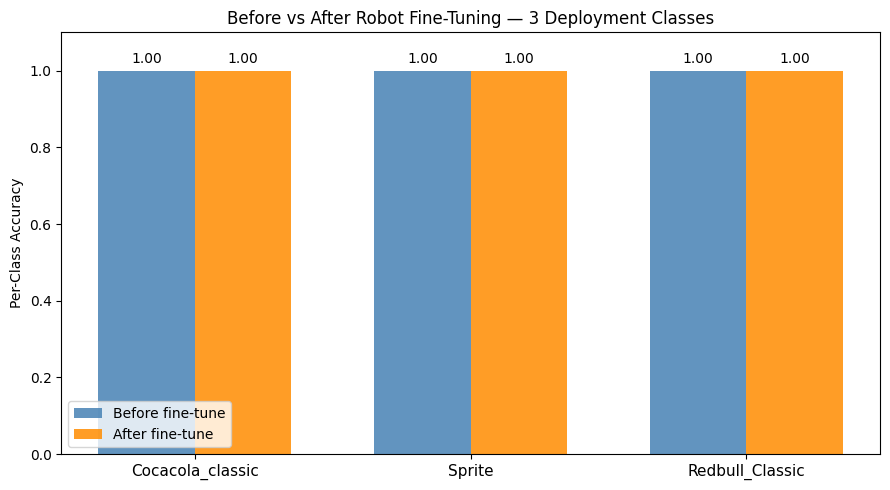

In [51]:
b_path = '../outputs/logs/before_robot_finetune_metrics.json'
a_path = '../outputs/logs/after_robot_finetune_metrics.json'

if os.path.exists(b_path) and os.path.exists(a_path):
    b = json.load(open(b_path))
    a = json.load(open(a_path))

    before_vals = [b['per_class_accuracy'].get(c, 0) for c in THREE_CLASSES]
    after_vals  = [a['per_class_accuracy'].get(c, 0) for c in THREE_CLASSES]

    x     = range(len(THREE_CLASSES))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar([i - width/2 for i in x], before_vals, width,
                   label='Before fine-tune', color='steelblue', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], after_vals, width,
                   label='After fine-tune', color='darkorange', alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels(THREE_CLASSES, fontsize=11)
    ax.set_ylabel('Per-Class Accuracy')
    ax.set_title('Before vs After Robot Fine-Tuning — 3 Deployment Classes')
    ax.set_ylim(0, 1.1)
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=10)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{bar.get_height():.2f}',
                ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('../outputs/plots/before_after_per_class.png', dpi=150)
    plt.show()
else:
    print('Run both evaluate.py commands first.')

## 12. Robot Actions Summary

| Class | Robot Action | Twist Values |
|-------|-------------|-------------|
| Cocacola_classic | Search → Align → Move forward | linear.x=0.1 |
| Sprite | Search → Align → Move forward | linear.x=0.1 |
| Redbull_Classic | Search → Align → Move forward | linear.x=0.1 |

**State machine:** SEARCH (rotate 0.15 rad/s) → ALIGN (centre object proportionally) → APPROACH (move forward) → ARRIVED (stop when close)

## 13. Discussion

### Why these three classes?
Cocacola_classic, Sprite, and Redbull_Classic were selected because sufficient robot-captured images were available for all three. They represent visually distinct products — red can, green can, and blue/silver can — which helps the classifier distinguish between them confidently. They also represent the most commonly available energy and soft drink categories in the lab environment.

### Why test on robot images before fine-tuning?
Testing the Phase 2 model directly on robot images (before any fine-tuning) shows how well a model trained on studio images generalises to robot camera conditions. This establishes a baseline and demonstrates whether fine-tuning is actually necessary.

### Why fine-tune on robot images?
Robot-captured images differ from the Phase 2 studio dataset due to motion blur, varying lighting, different viewing angles, and background clutter. Fine-tuning on a small set of robot images adapts the model to these conditions, typically improving accuracy on the deployment environment.

### Why MobileNetV3-Large?
MobileNetV3-Large was selected for Phase 3 deployment because it achieves higher ImageNet accuracy (74.0%) than both ResNet18 (69.8%) and VGG16 (71.6%) used in Phase 2, while being significantly more lightweight (5.4M parameters vs 138M for VGG16) and faster at inference on CPU — a critical requirement for real-time robot deployment.

### ROI Detection Approach
Object detection uses OpenCV contour extraction (Canny edges → dilation → findContours). An aspect ratio filter (0.15 < w/h < 1.2) eliminates face and body detections since drink cans are tall and narrow. This approach requires no additional model and runs in real time on the robot CPU.

### Limitations
- Contour detection is sensitive to background clutter and lighting changes
- Only 3 of 20 classes are deployed on the robot due to time constraints
- Robot images were merged with clean_dataset rather than kept fully separate

### Future Improvements
- Train YOLOv8-nano with annotated bounding boxes for robust detection
- Use depth camera data to control approach distance precisely
- Expand robot deployment to all 20 classes